In [1]:
import sys
import random
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import joblib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from datasets import load_dataset, disable_progress_bars
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from src.config import OUTPUTS, IMG_SIZE, MLP_IMG_SIZE, SEED
from src.mlp import MLP
from src.cnn import CNN
from src.transfer import build_feature_extractor, build_fine_tuner
from src.data import get_transforms

torch.manual_seed(SEED)
random.seed(SEED)

# Generalización Fuera de Dominio - Evaluación sobre itw-sm

En el notebook 05 se observó que los modelos fallan sobre fotos cotidianas (una selfie real fue clasificada como generada por IA por tres de los cuatro modelos). Esa evidencia, sin embargo, se basa en unas pocas imágenes propias.

Este notebook cuantifica esa limitación: se evalúan los **cuatro modelos base** (MLP, CNN, Transfer FE y Transfer FT) sobre un conjunto de test de **itw-sm** (In The Wild - Social Media), un dataset de imágenes reales y generadas por IA extraídas de redes sociales (Facebook, X, Instagram y LinkedIn), con contenido cotidiano similar al que subiría un usuario común.

La pregunta que responde este experimento: **¿el problema de generalización es de alguna arquitectura en particular, o del dominio de entrenamiento?** Si todos los modelos fallan por igual, significa que la limitación está en los datos (paisajes, naturaleza y arte) y no en los modelos, lo que motiva la adaptación de dominio del notebook 07.

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

pca = joblib.load(OUTPUTS / "pca_mlp.joblib")

mlp_model = MLP(input_dim=pca.n_components_)
mlp_model.load_state_dict(torch.load(OUTPUTS / "mlp_best.pt", map_location="cpu"))
mlp_model.eval()

cnn_model = CNN()
cnn_model.load_state_dict(torch.load(OUTPUTS / "cnn_best.pt", map_location="cpu"))
cnn_model = cnn_model.to(device)
cnn_model.eval()

fe_model = build_feature_extractor()
fe_model.load_state_dict(torch.load(OUTPUTS / "fe_best.pt", map_location="cpu"))
fe_model = fe_model.to(device)
fe_model.eval()

ft_model = build_fine_tuner()
ft_model.load_state_dict(torch.load(OUTPUTS / "ft_best.pt", map_location="cpu"))
ft_model = ft_model.to(device)
ft_model.eval()

print("Modelos cargados.")

Dispositivo: mps
Modelos cargados.


## 1. Carga del dataset y test set

Se reserva el **mismo 10% de test** que utilizará el notebook 07 para el fine-tuning incremental (misma semilla y mismo orden de operaciones al hacer el split). Esto garantiza dos cosas:

- Las comparaciones antes/después de la adaptación se hacen sobre el mismo conjunto de imágenes.
- Ninguna de las imágenes evaluadas acá se usa luego para entrenar.

In [3]:
disable_progress_bars()

ds = load_dataset("dkarageo/itw-sm")

# El nombre del split varía según el dataset (se toma el primero disponible)
split_name = list(ds.keys())[0]
data = ds[split_name]

targets = data["target"]
real_items = [i for i, t in enumerate(targets) if t == 0]
fake_items = [i for i, t in enumerate(targets) if t == 1]

random.shuffle(real_items)
random.shuffle(fake_items)

samples = [(idx, 0) for idx in real_items] + [(idx, 1) for idx in fake_items]
labels = [s[1] for s in samples]

train_val_s, test_itw_s = train_test_split(samples, test_size=0.10, stratify=labels, random_state=SEED)

n_real = sum(1 for _, l in test_itw_s if l == 0)
n_fake = sum(1 for _, l in test_itw_s if l == 1)
print(f"Test itw-sm: {len(test_itw_s)} imágenes ({n_real} reales / {n_fake} generadas)")

Test itw-sm: 1000 imágenes (500 reales / 500 generadas)


## 2. Evaluación de los cuatro modelos

Los modelos CNN, FE y FT reciben las imágenes con el mismo preprocesamiento que en entrenamiento (224x224 + normalización ImageNet). El MLP usa su propio camino: redimensionado a 128x128, aplanado y proyección con el PCA ajustado en el notebook 02.

In [4]:
# Dataset que carga cada imagen desde HuggingFace solo cuando se necesita
class PILDataset:
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        data_idx, label = self.samples[idx]
        img = data[data_idx]["image"].convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        return self.transform(img), label


test_itw_loader = DataLoader(PILDataset(test_itw_s, get_transforms("val")), batch_size=32)


def evaluar_conv(model):
    """
    Evalúa un modelo convolucional (CNN / FE / FT) sobre el test de itw-sm.
    """
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbs in test_itw_loader:
            preds = (model(imgs.to(device)).sigmoid() >= 0.5).int().squeeze().cpu()
            all_preds.append(preds)
            all_labels.append(lbs)
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()


def evaluar_mlp():
    """
    Evalúa el MLP: redimensiona a 128x128, aplana y proyecta con PCA.
    """
    filas, lbs = [], []
    for data_idx, label in test_itw_s:
        img = data[data_idx]["image"].convert("RGB").resize((MLP_IMG_SIZE, MLP_IMG_SIZE))
        filas.append(np.array(img, dtype=np.uint8).flatten())
        lbs.append(label)
    X = pca.transform(np.stack(filas)).astype(np.float32)
    with torch.no_grad():
        preds = (mlp_model(torch.from_numpy(X)).sigmoid() >= 0.5).int().squeeze().numpy()
    return preds, np.array(lbs)


def metricas(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }


resultados = {}

y_pred_mlp, y_true_mlp = evaluar_mlp()
resultados["MLP"] = metricas(y_true_mlp, y_pred_mlp)
print("MLP evaluado.")

for nombre, model in [("CNN", cnn_model), ("Transfer FE", fe_model), ("Transfer FT", ft_model)]:
    y_pred, y_true = evaluar_conv(model)
    resultados[nombre] = metricas(y_true, y_pred)
    print(f"{nombre} evaluado.")

df_itw = pd.DataFrame(resultados).T
print()
print(df_itw.to_string(float_format=lambda x: f"{x:.4f}"))

MLP evaluado.
CNN evaluado.
Transfer FE evaluado.
Transfer FT evaluado.

             Accuracy  Precision  Recall     F1
MLP            0.5650     0.5429  0.8220 0.6539
CNN            0.6440     0.5933  0.9160 0.7201
Transfer FE    0.6070     0.5647  0.9340 0.7038
Transfer FT    0.6230     0.5723  0.9740 0.7209


## 3. Comparación con el dominio original

Se contrasta la accuracy de cada modelo sobre el test set original (calculada en el notebook 05) con la obtenida sobre itw-sm.

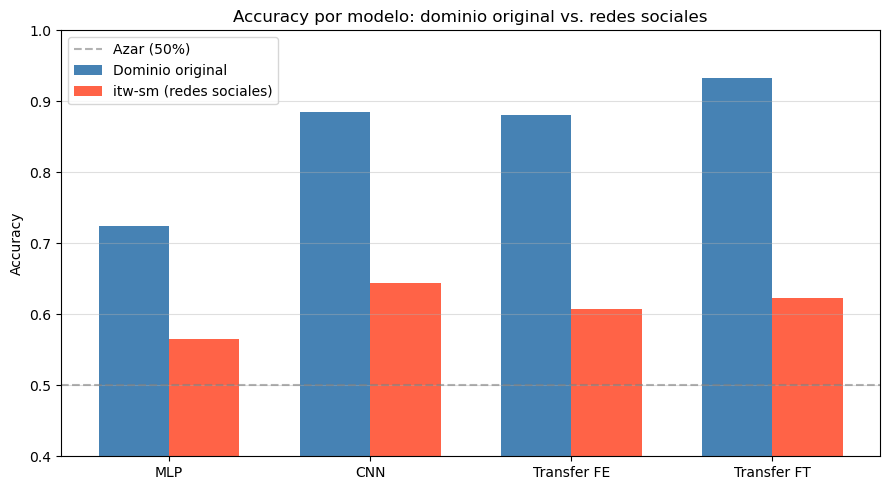

In [5]:
# Accuracies sobre el test set original (notebook 05)
acc_original = {"MLP": 0.7237, "CNN": 0.8843, "Transfer FE": 0.8808, "Transfer FT": 0.9335}

modelos = list(acc_original.keys())
acc_orig = [acc_original[m] for m in modelos]
acc_itw = [resultados[m]["Accuracy"] for m in modelos]

x = range(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i - width/2 for i in x], acc_orig, width=width, label="Dominio original", color="steelblue")
ax.bar([i + width/2 for i in x], acc_itw, width=width, label="itw-sm (redes sociales)", color="tomato")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.6, label="Azar (50%)")
ax.set_xticks(list(x))
ax.set_xticklabels(modelos)
ax.set_ylim(0.4, 1.0)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy por modelo: dominio original vs. redes sociales")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

### Conclusión

Todos los modelos sufren una caída drástica al pasar del dominio original a las imágenes de redes sociales, quedando cerca del azar (50%). Ninguna arquitectura escapa al problema: ni el MLP, ni la CNN entrenada desde cero, ni los dos modelos de transfer learning.

Esto confirma que la limitación **no es de los modelos sino del dominio de entrenamiento**: las imágenes "reales" que vieron durante el entrenamiento son exclusivamente paisajes, naturaleza, arquitectura y arte, por lo que ninguno aprendió a reconocer una foto cotidiana como real.

La solución, entonces, no pasa por cambiar de arquitectura sino por **adaptar el dominio**: en el notebook 07 se toma el modelo Transfer FT y se le aplica un fine-tuning incremental con las imágenes de train de itw-sm.

**¿Por qué se adapta el Transfer FT y no la CNN**, si esta da apenas mejor en itw-sm (64.4% vs 62.3%)? Porque la realidad es que esa diferencia de 2 puntos sobre 1000 imágenes no es significativa, ambos están igual de perdidos en este dominio. Lo que sí importa para elegir el punto de partida es otra cosa:

- El FT es claramente superior en el dominio original (93.4% vs 88.4%), y el objetivo es un modelo que funcione bien en **ambos** dominios tras la adaptación.
- Las capas congeladas del FT (layer1-3 de ResNet50) traen features de ImageNet, que incluye fotos cotidianas de personas, comida y objetos, que son mucho más aptos para adaptarse a redes sociales que los features de la CNN, aprendidos exclusivamente sobre paisajes y arte.